# 📊 Data Analytics Metrics Tutorial

## Learning Objectives

By the end of this tutorial, you will:
- Understand key data analytics metrics and their mathematical formulas
- Learn what R² (R-squared) means and how to interpret it
- Understand correlation and how to measure it
- Learn about error metrics: MAE, RMSE, MSE
- See visual comparisons of good vs bad model performance
- Practice calculating metrics yourself

---

## What Are Metrics?

**Metrics** are numerical measures that help us:
- **Evaluate** how well our models perform
- **Compare** different models
- **Understand** relationships in data
- **Make decisions** about which approach is best

Think of metrics as **scores** that tell us how good something is!

---

## Step 1: Import Libraries and Create Sample Data

We'll create simple example datasets to demonstrate each metric clearly.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')

sns.set_palette("husl")
%matplotlib inline

print("✅ Libraries imported successfully!")

# Set random seed for reproducibility
np.random.seed(42)

✅ Libraries imported successfully!


In [2]:
# Create sample datasets for demonstrations

# Dataset 1: Perfect linear relationship (for good R² example)
x1 = np.linspace(0, 100, 50)
y1_actual = 2 * x1 + 10 + np.random.normal(0, 2, 50)  # y = 2x + 10 + small noise
y1_predicted_good = 2 * x1 + 10  # Perfect predictions
y1_predicted_bad = np.random.normal(50, 20, 50)  # Random predictions

# Dataset 2: Moderate relationship (for moderate R² example)
x2 = np.linspace(0, 100, 50)
y2_actual = 1.5 * x2 + 5 + np.random.normal(0, 15, 50)  # More noise
y2_predicted = 1.5 * x2 + 5  # Good predictions

# Dataset 3: Weak relationship (for low R² example)
x3 = np.linspace(0, 100, 50)
y3_actual = 0.3 * x3 + 30 + np.random.normal(0, 25, 50)  # Lots of noise
y3_predicted = 0.3 * x3 + 30  # Predictions follow weak pattern

print("✅ Sample datasets created!")
print(f"\nDataset 1: {len(x1)} points (strong relationship)")
print(f"Dataset 2: {len(x2)} points (moderate relationship)")
print(f"Dataset 3: {len(x3)} points (weak relationship)")

✅ Sample datasets created!

Dataset 1: 50 points (strong relationship)
Dataset 2: 50 points (moderate relationship)
Dataset 3: 50 points (weak relationship)


## Step 2: Understanding R² (R-Squared / Coefficient of Determination)

### What is R²?

**R² (R-squared)** tells us **how well our predictions fit the actual data**.

### The Mathematical Formula:

```
R² = 1 - (SS_res / SS_tot)
```

Where:
- **SS_res** (Sum of Squared Residuals) = Σ(actual - predicted)²
- **SS_tot** (Total Sum of Squares) = Σ(actual - mean)²

### What R² Means:

R² represents the **proportion of variance** in the actual values that is explained by our predictions.

### Interpretation:

| R² Value | Interpretation | Meaning |
|----------|---------------|---------|
| **1.0** | Perfect fit | Model explains 100% of variance |
| **0.8 - 0.99** | Excellent | Model explains 80-99% of variance |
| **0.6 - 0.79** | Good | Model explains 60-79% of variance |
| **0.4 - 0.59** | Moderate | Model explains 40-59% of variance |
| **0.2 - 0.39** | Weak | Model explains 20-39% of variance |
| **0.0 - 0.19** | Very Weak | Model explains <20% of variance |
| **< 0.0** | Worse than mean | Model is worse than just predicting the average! |

### Visual Understanding:

- **R² = 1.0**: All points lie exactly on the prediction line
- **R² = 0.0**: Predictions are as good as just using the mean
- **R² < 0**: Predictions are worse than using the mean!

In [3]:
# Calculate R² for different scenarios

# Good predictions (follow the pattern)
r2_good = r2_score(y1_actual, y1_predicted_good)

# Bad predictions (random)
r2_bad = r2_score(y1_actual, y1_predicted_bad)

# Moderate predictions
r2_moderate = r2_score(y2_actual, y2_predicted)

# Weak relationship
r2_weak = r2_score(y3_actual, y3_predicted)

print("📊 R² (R-Squared) Scores:")
print("=" * 60)
print(f"\n✅ Good Model (strong relationship):     R² = {r2_good:.4f}")
print(f"📈 Moderate Model (moderate relationship): R² = {r2_moderate:.4f}")
print(f"⚠️  Weak Model (weak relationship):        R² = {r2_weak:.4f}")
print(f"❌ Bad Model (random predictions):          R² = {r2_bad:.4f}")

print("\n💡 Interpretation:")
print(f"   - Good model explains {r2_good*100:.1f}% of variance")
print(f"   - Bad model explains {r2_bad*100:.1f}% of variance (worse than mean!)")

📊 R² (R-Squared) Scores:

✅ Good Model (strong relationship):     R² = 0.9989
📈 Moderate Model (moderate relationship): R² = 0.8932
⚠️  Weak Model (weak relationship):        R² = 0.0112
❌ Bad Model (random predictions):          R² = -1.1676

💡 Interpretation:
   - Good model explains 99.9% of variance
   - Bad model explains -116.8% of variance (worse than mean!)


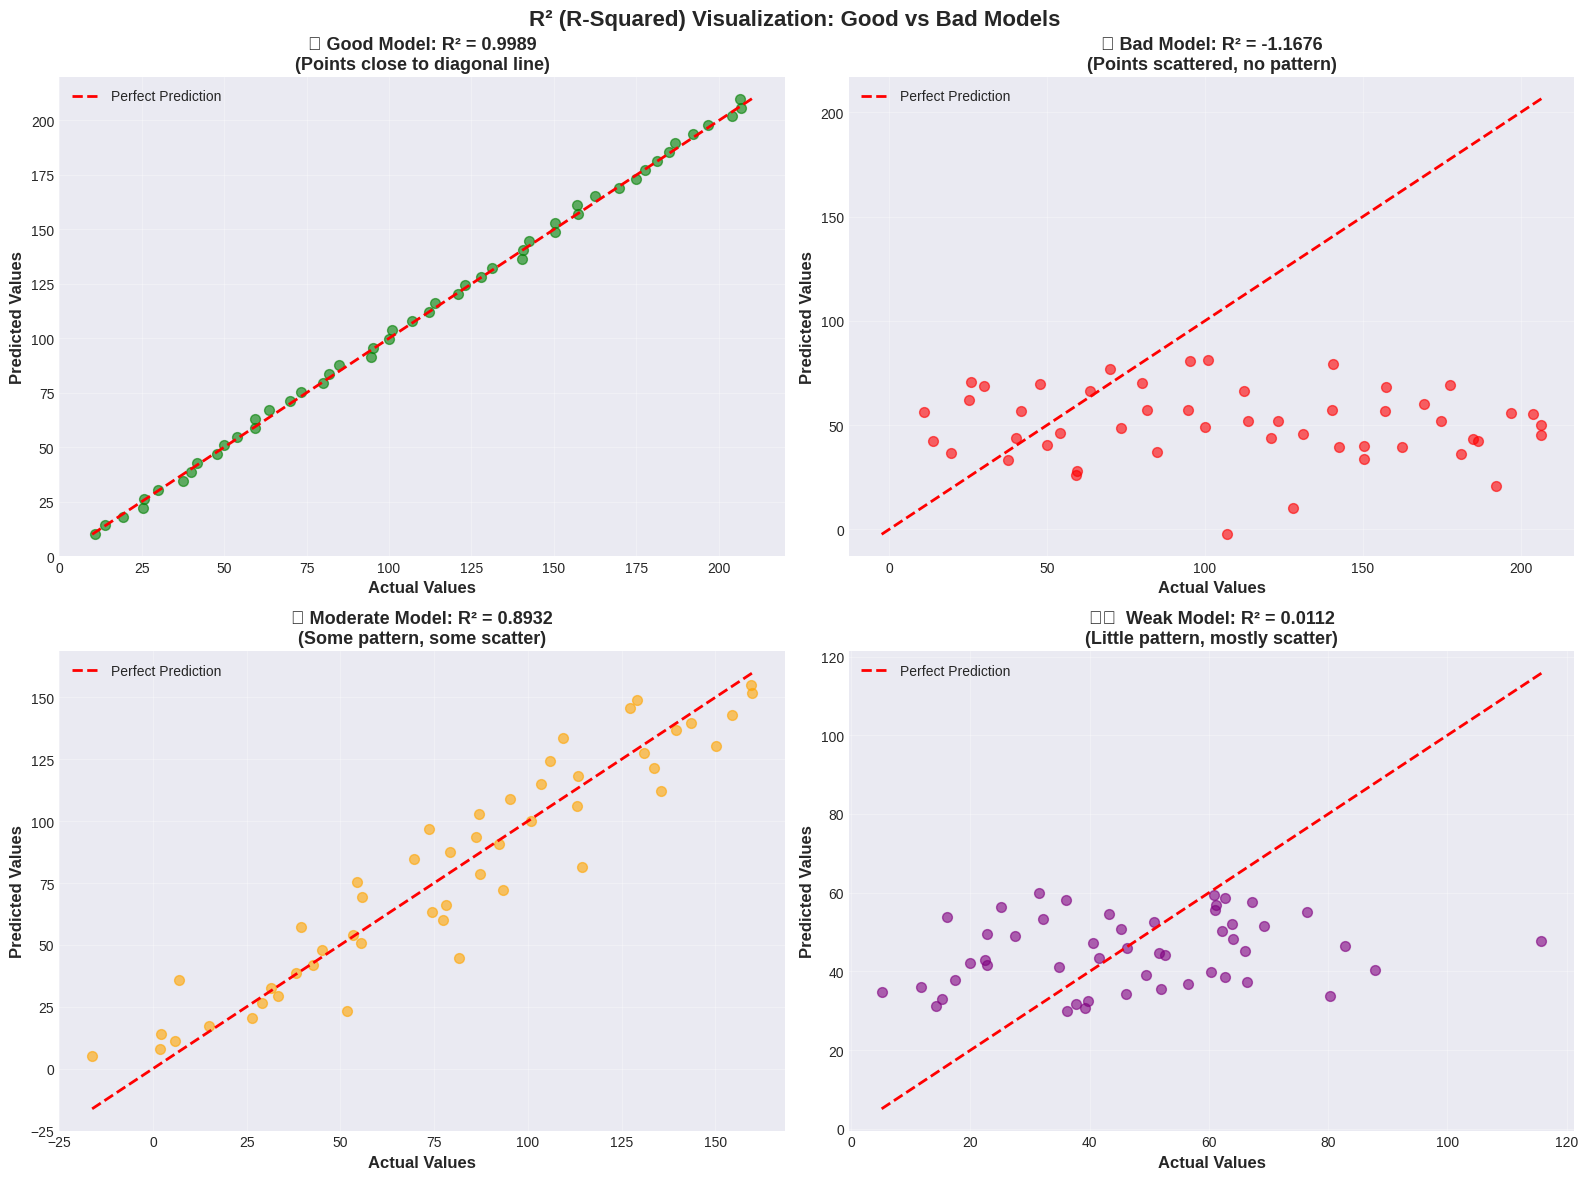

✅ R² visualization created!

💡 Key Takeaway:
   - Higher R² = Points closer to diagonal line = Better model
   - Lower R² = Points more scattered = Worse model


In [4]:
# Visualize R²: Good vs Bad Predictions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('R² (R-Squared) Visualization: Good vs Bad Models', fontsize=16, fontweight='bold')

# Plot 1: Good Model (High R²)
axes[0, 0].scatter(y1_actual, y1_predicted_good, alpha=0.6, s=50, color='green')
min_val = min(min(y1_actual), min(y1_predicted_good))
max_val = max(max(y1_actual), max(y1_predicted_good))
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[0, 0].set_title(f'✅ Good Model: R² = {r2_good:.4f}\n(Points close to diagonal line)', 
                     fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Bad Model (Low/Negative R²)
axes[0, 1].scatter(y1_actual, y1_predicted_bad, alpha=0.6, s=50, color='red')
min_val = min(min(y1_actual), min(y1_predicted_bad))
max_val = max(max(y1_actual), max(y1_predicted_bad))
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[0, 1].set_title(f'❌ Bad Model: R² = {r2_bad:.4f}\n(Points scattered, no pattern)', 
                     fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Moderate Model
axes[1, 0].scatter(y2_actual, y2_predicted, alpha=0.6, s=50, color='orange')
min_val = min(min(y2_actual), min(y2_predicted))
max_val = max(max(y2_actual), max(y2_predicted))
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 0].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[1, 0].set_title(f'📈 Moderate Model: R² = {r2_moderate:.4f}\n(Some pattern, some scatter)', 
                     fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Weak Model
axes[1, 1].scatter(y3_actual, y3_predicted, alpha=0.6, s=50, color='purple')
min_val = min(min(y3_actual), min(y3_predicted))
max_val = max(max(y3_actual), max(y3_predicted))
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Values', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Predicted Values', fontsize=12, fontweight='bold')
axes[1, 1].set_title(f'⚠️  Weak Model: R² = {r2_weak:.4f}\n(Little pattern, mostly scatter)', 
                     fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ R² visualization created!")
print("\n💡 Key Takeaway:")
print("   - Higher R² = Points closer to diagonal line = Better model")
print("   - Lower R² = Points more scattered = Worse model")

## Step 3: Understanding Correlation

### What is Correlation?

**Correlation** measures how two variables **change together** (move in the same or opposite directions).

### The Mathematical Formula (Pearson Correlation):

```
r = Σ[(x - x̄)(y - ȳ)] / √[Σ(x - x̄)² × Σ(y - ȳ)²]
```

Where:
- **x̄** = mean of x
- **ȳ** = mean of y
- **r** = correlation coefficient

### Correlation Values:

| Correlation (r) | Interpretation | Meaning |
|-----------------|---------------|---------|
| **+1.0** | Perfect positive | Both increase together perfectly |
| **+0.7 to +0.9** | Strong positive | Strong tendency to increase together |
| **+0.4 to +0.6** | Moderate positive | Moderate tendency to increase together |
| **+0.1 to +0.3** | Weak positive | Weak tendency to increase together |
| **0.0** | No correlation | No relationship |
| **-0.1 to -0.3** | Weak negative | Weak tendency to move opposite |
| **-0.4 to -0.6** | Moderate negative | Moderate tendency to move opposite |
| **-0.7 to -0.9** | Strong negative | Strong tendency to move opposite |
| **-1.0** | Perfect negative | Perfect opposite movement |

### Important Notes:

⚠️ **Correlation ≠ Causation**
- Correlation means variables are related
- It does NOT mean one causes the other!
- Example: Ice cream sales and drowning (both increase in summer, but one doesn't cause the other)

### Correlation vs R²:

- **Correlation (r)**: Measures linear relationship strength (-1 to +1)
- **R²**: Measures how well predictions fit (0 to 1, can be negative)
- **Relationship**: R² = r² (for simple linear regression)

In [5]:
# Create datasets with different correlation strengths

# Strong positive correlation
x_strong_pos = np.linspace(0, 100, 50)
y_strong_pos = 2 * x_strong_pos + 10 + np.random.normal(0, 5, 50)

# Moderate positive correlation
x_moderate = np.linspace(0, 100, 50)
y_moderate = 1.5 * x_moderate + 20 + np.random.normal(0, 20, 50)

# Weak correlation
x_weak = np.linspace(0, 100, 50)
y_weak = 0.3 * x_weak + 50 + np.random.normal(0, 30, 50)

# Strong negative correlation
x_strong_neg = np.linspace(0, 100, 50)
y_strong_neg = -2 * x_strong_neg + 200 + np.random.normal(0, 5, 50)

# No correlation (random)
x_no_corr = np.linspace(0, 100, 50)
y_no_corr = np.random.normal(50, 15, 50)

# Calculate correlations
corr_strong_pos, _ = pearsonr(x_strong_pos, y_strong_pos)
corr_moderate, _ = pearsonr(x_moderate, y_moderate)
corr_weak, _ = pearsonr(x_weak, y_weak)
corr_strong_neg, _ = pearsonr(x_strong_neg, y_strong_neg)
corr_no, _ = pearsonr(x_no_corr, y_no_corr)

print("📊 Correlation Coefficients:")
print("=" * 60)
print(f"\n✅ Strong Positive:    r = {corr_strong_pos:+.4f}")
print(f"📈 Moderate Positive:  r = {corr_moderate:+.4f}")
print(f"⚠️  Weak Positive:       r = {corr_weak:+.4f}")
print(f"❌ Strong Negative:     r = {corr_strong_neg:+.4f}")
print(f"🔀 No Correlation:      r = {corr_no:+.4f}")

📊 Correlation Coefficients:

✅ Strong Positive:    r = +0.9958
📈 Moderate Positive:  r = +0.9086
⚠️  Weak Positive:       r = +0.0523
❌ Strong Negative:     r = -0.9966
🔀 No Correlation:      r = -0.1124


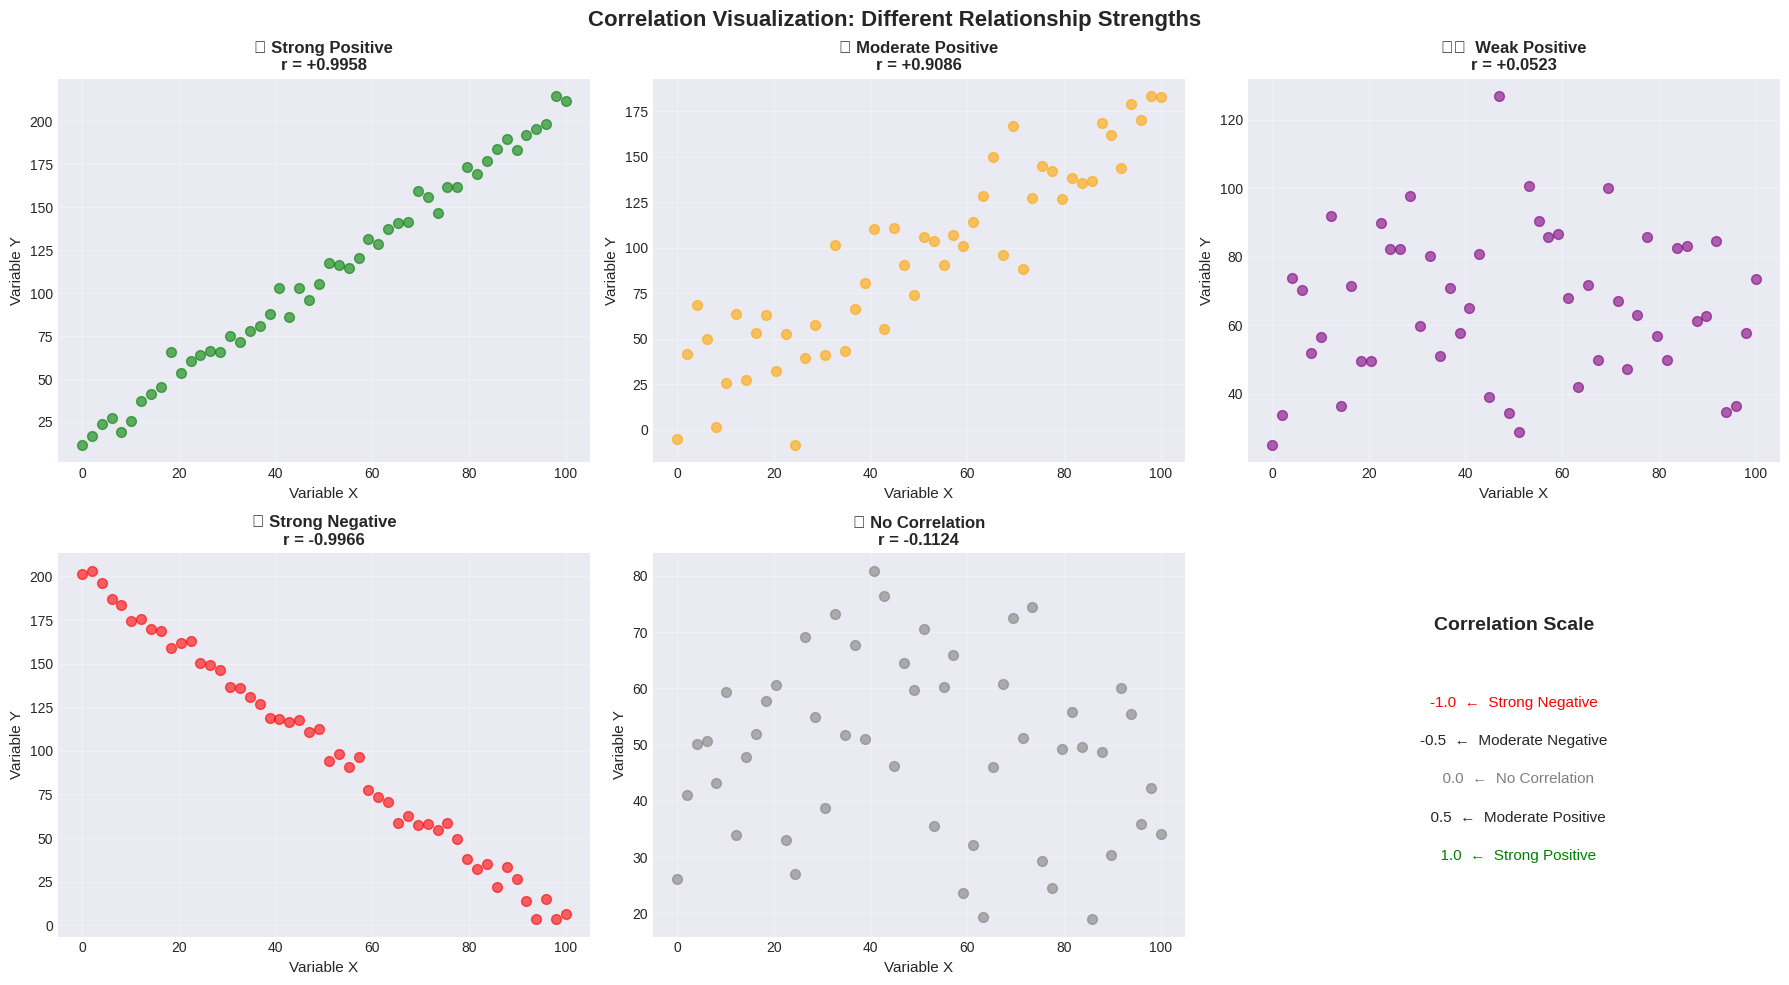

✅ Correlation visualization created!

💡 Key Takeaway:
   - Positive r: Variables increase together
   - Negative r: One increases, other decreases
   - |r| close to 1: Strong relationship
   - |r| close to 0: Weak/no relationship


In [6]:
# Visualize different correlation strengths
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Correlation Visualization: Different Relationship Strengths', fontsize=16, fontweight='bold')

# Strong positive correlation
axes[0, 0].scatter(x_strong_pos, y_strong_pos, alpha=0.6, s=50, color='green')
axes[0, 0].set_xlabel('Variable X', fontsize=11)
axes[0, 0].set_ylabel('Variable Y', fontsize=11)
axes[0, 0].set_title(f'✅ Strong Positive\nr = {corr_strong_pos:+.4f}', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Moderate positive correlation
axes[0, 1].scatter(x_moderate, y_moderate, alpha=0.6, s=50, color='orange')
axes[0, 1].set_xlabel('Variable X', fontsize=11)
axes[0, 1].set_ylabel('Variable Y', fontsize=11)
axes[0, 1].set_title(f'📈 Moderate Positive\nr = {corr_moderate:+.4f}', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Weak correlation
axes[0, 2].scatter(x_weak, y_weak, alpha=0.6, s=50, color='purple')
axes[0, 2].set_xlabel('Variable X', fontsize=11)
axes[0, 2].set_ylabel('Variable Y', fontsize=11)
axes[0, 2].set_title(f'⚠️  Weak Positive\nr = {corr_weak:+.4f}', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Strong negative correlation
axes[1, 0].scatter(x_strong_neg, y_strong_neg, alpha=0.6, s=50, color='red')
axes[1, 0].set_xlabel('Variable X', fontsize=11)
axes[1, 0].set_ylabel('Variable Y', fontsize=11)
axes[1, 0].set_title(f'❌ Strong Negative\nr = {corr_strong_neg:+.4f}', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# No correlation
axes[1, 1].scatter(x_no_corr, y_no_corr, alpha=0.6, s=50, color='gray')
axes[1, 1].set_xlabel('Variable X', fontsize=11)
axes[1, 1].set_ylabel('Variable Y', fontsize=11)
axes[1, 1].set_title(f'🔀 No Correlation\nr = {corr_no:+.4f}', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Correlation scale reference
axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.8, 'Correlation Scale', ha='center', fontsize=14, fontweight='bold', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.5, 0.6, '-1.0  ←  Strong Negative', ha='center', fontsize=11, color='red', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.5, 0.5, '-0.5  ←  Moderate Negative', ha='center', fontsize=11, transform=axes[1, 2].transAxes)
axes[1, 2].text(0.5, 0.4, '  0.0  ←  No Correlation', ha='center', fontsize=11, color='gray', transform=axes[1, 2].transAxes)
axes[1, 2].text(0.5, 0.3, '  0.5  ←  Moderate Positive', ha='center', fontsize=11, transform=axes[1, 2].transAxes)
axes[1, 2].text(0.5, 0.2, '  1.0  ←  Strong Positive', ha='center', fontsize=11, color='green', transform=axes[1, 2].transAxes)

plt.tight_layout()
plt.show()

print("✅ Correlation visualization created!")
print("\n💡 Key Takeaway:")
print("   - Positive r: Variables increase together")
print("   - Negative r: One increases, other decreases")
print("   - |r| close to 1: Strong relationship")
print("   - |r| close to 0: Weak/no relationship")

## Step 4: Error Metrics (MAE, RMSE, MSE)

These metrics measure **how wrong** our predictions are.

### 1. MAE (Mean Absolute Error)

**Formula**:
```
MAE = (1/n) × Σ|actual - predicted|
```

**What it means**:
- Average of **absolute** errors
- Treats all errors equally
- Same units as the target variable
- Easy to interpret

**Example**:
- If MAE = 5, on average predictions are off by 5 units

### 2. MSE (Mean Squared Error)

**Formula**:
```
MSE = (1/n) × Σ(actual - predicted)²
```

**What it means**:
- Average of **squared** errors
- Penalizes large errors more heavily
- Units are squared (harder to interpret)
- Used in optimization (differentiable)

**Example**:
- If MSE = 25, average squared error is 25
- This means average error is about √25 = 5 units

### 3. RMSE (Root Mean Squared Error)

**Formula**:
```
RMSE = √MSE = √[(1/n) × Σ(actual - predicted)²]
```

**What it means**:
- Square root of MSE
- Same units as target variable (easier to interpret)
- Also penalizes large errors
- Most commonly used in practice

**Example**:
- If RMSE = 5, predictions are off by about 5 units on average

### Comparison:

| Metric | Formula | Units | Penalizes Large Errors? | Interpretability |
|--------|---------|-------|-------------------------|------------------|
| **MAE** | Average of |absolute errors| | Same as target | No | Easy |
| **MSE** | Average of |squared errors| | Squared | Yes (heavily) | Hard |
| **RMSE** | √MSE | Same as target | Yes | Easy |

### When to Use:

- **MAE**: When all errors are equally important
- **RMSE**: When large errors are very bad (most common)
- **MSE**: For mathematical optimization (rarely reported)

In [7]:
# Calculate error metrics for good vs bad predictions

# Good predictions
mae_good = mean_absolute_error(y1_actual, y1_predicted_good)
mse_good = mean_squared_error(y1_actual, y1_predicted_good)
rmse_good = np.sqrt(mse_good)

# Bad predictions
mae_bad = mean_absolute_error(y1_actual, y1_predicted_bad)
mse_bad = mean_squared_error(y1_actual, y1_predicted_bad)
rmse_bad = np.sqrt(mse_bad)

print("📊 Error Metrics Comparison: Good vs Bad Model")
print("=" * 70)
print(f"\n{'Metric':<10} {'Good Model':<20} {'Bad Model':<20}")
print("-" * 70)
print(f"{'MAE':<10} {mae_good:<20.2f} {mae_bad:<20.2f}")
print(f"{'MSE':<10} {mse_good:<20.2f} {mse_bad:<20.2f}")
print(f"{'RMSE':<10} {rmse_good:<20.2f} {rmse_bad:<20.2f}")

print("\n💡 Interpretation:")
print(f"   - Good model: Average error is ~{rmse_good:.1f} units")
print(f"   - Bad model: Average error is ~{rmse_bad:.1f} units")
print(f"   - Bad model has {rmse_bad/rmse_good:.1f}x larger errors!")

📊 Error Metrics Comparison: Good vs Bad Model

Metric     Good Model           Bad Model           
----------------------------------------------------------------------
MAE        1.53                 69.64               
MSE        3.62                 7440.51             
RMSE       1.90                 86.26               

💡 Interpretation:
   - Good model: Average error is ~1.9 units
   - Bad model: Average error is ~86.3 units
   - Bad model has 45.3x larger errors!


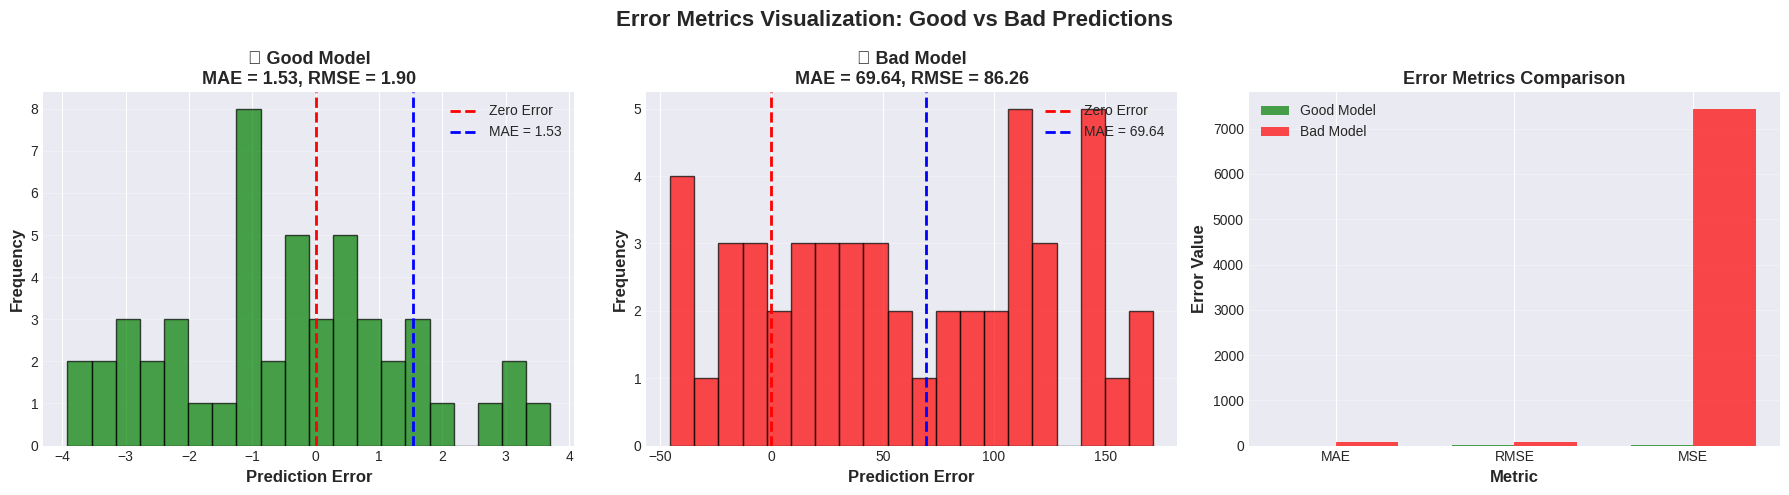

✅ Error metrics visualization created!


In [8]:
# Visualize error metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error Metrics Visualization: Good vs Bad Predictions', fontsize=16, fontweight='bold')

# Calculate errors for visualization
errors_good = y1_actual - y1_predicted_good
errors_bad = y1_actual - y1_predicted_bad

# Plot 1: Error distribution (Good model)
axes[0].hist(errors_good, bins=20, alpha=0.7, color='green', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].axvline(x=mae_good, color='blue', linestyle='--', linewidth=2, label=f'MAE = {mae_good:.2f}')
axes[0].set_xlabel('Prediction Error', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title(f'✅ Good Model\nMAE = {mae_good:.2f}, RMSE = {rmse_good:.2f}', 
                 fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Error distribution (Bad model)
axes[1].hist(errors_bad, bins=20, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=mae_bad, color='blue', linestyle='--', linewidth=2, label=f'MAE = {mae_bad:.2f}')
axes[1].set_xlabel('Prediction Error', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'❌ Bad Model\nMAE = {mae_bad:.2f}, RMSE = {rmse_bad:.2f}', 
                 fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Plot 3: Comparison bar chart
metrics = ['MAE', 'RMSE', 'MSE']
good_values = [mae_good, rmse_good, mse_good]
bad_values = [mae_bad, rmse_bad, mse_bad]

x = np.arange(len(metrics))
width = 0.35

axes[2].bar(x - width/2, good_values, width, label='Good Model', color='green', alpha=0.7)
axes[2].bar(x + width/2, bad_values, width, label='Bad Model', color='red', alpha=0.7)
axes[2].set_xlabel('Metric', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Error Value', fontsize=12, fontweight='bold')
axes[2].set_title('Error Metrics Comparison', fontsize=13, fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✅ Error metrics visualization created!")

## Step 5: Manual Calculation Examples

Let's calculate these metrics manually to understand the math!

In [9]:
# Simple example for manual calculation
actual_simple = np.array([10, 20, 30, 40, 50])
predicted_simple = np.array([12, 18, 32, 38, 52])

print("📐 Manual Calculation Example:")
print("=" * 60)
print(f"\nActual values:    {actual_simple}")
print(f"Predicted values: {predicted_simple}")

# Calculate errors
errors = actual_simple - predicted_simple
print(f"\nErrors:           {errors}")

# Manual MAE calculation
mae_manual = np.mean(np.abs(errors))
print(f"\n📊 MAE (Mean Absolute Error):")
print(f"   Formula: (1/n) × Σ|errors|")
print(f"   Calculation: (1/5) × ({np.abs(errors[0])} + {np.abs(errors[1])} + {np.abs(errors[2])} + {np.abs(errors[3])} + {np.abs(errors[4])})")
print(f"   MAE = {mae_manual:.2f}")

# Manual MSE calculation
mse_manual = np.mean(errors ** 2)
print(f"\n📊 MSE (Mean Squared Error):")
print(f"   Formula: (1/n) × Σ(errors)²")
print(f"   Calculation: (1/5) × ({errors[0]**2:.0f} + {errors[1]**2:.0f} + {errors[2]**2:.0f} + {errors[3]**2:.0f} + {errors[4]**2:.0f})")
print(f"   MSE = {mse_manual:.2f}")

# Manual RMSE calculation
rmse_manual = np.sqrt(mse_manual)
print(f"\n📊 RMSE (Root Mean Squared Error):")
print(f"   Formula: √MSE")
print(f"   Calculation: √{mse_manual:.2f}")
print(f"   RMSE = {rmse_manual:.2f}")

# Manual R² calculation
mean_actual = np.mean(actual_simple)
ss_res = np.sum((actual_simple - predicted_simple) ** 2)  # Sum of squared residuals
ss_tot = np.sum((actual_simple - mean_actual) ** 2)  # Total sum of squares
r2_manual = 1 - (ss_res / ss_tot)

print(f"\n📊 R² (R-Squared):")
print(f"   Formula: 1 - (SS_res / SS_tot)")
print(f"   SS_res (Sum of Squared Residuals) = {ss_res:.2f}")
print(f"   SS_tot (Total Sum of Squares) = {ss_tot:.2f}")
print(f"   Mean of actual values = {mean_actual:.2f}")
print(f"   R² = 1 - ({ss_res:.2f} / {ss_tot:.2f}) = {r2_manual:.4f}")

# Verify with sklearn
print(f"\n✅ Verification (using sklearn):")
print(f"   MAE: {mean_absolute_error(actual_simple, predicted_simple):.2f}")
print(f"   MSE: {mean_squared_error(actual_simple, predicted_simple):.2f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(actual_simple, predicted_simple)):.2f}")
print(f"   R²: {r2_score(actual_simple, predicted_simple):.4f}")

📐 Manual Calculation Example:

Actual values:    [10 20 30 40 50]
Predicted values: [12 18 32 38 52]

Errors:           [-2  2 -2  2 -2]

📊 MAE (Mean Absolute Error):
   Formula: (1/n) × Σ|errors|
   Calculation: (1/5) × (2 + 2 + 2 + 2 + 2)
   MAE = 2.00

📊 MSE (Mean Squared Error):
   Formula: (1/n) × Σ(errors)²
   Calculation: (1/5) × (4 + 4 + 4 + 4 + 4)
   MSE = 4.00

📊 RMSE (Root Mean Squared Error):
   Formula: √MSE
   Calculation: √4.00
   RMSE = 2.00

📊 R² (R-Squared):
   Formula: 1 - (SS_res / SS_tot)
   SS_res (Sum of Squared Residuals) = 20.00
   SS_tot (Total Sum of Squares) = 1000.00
   Mean of actual values = 30.00
   R² = 1 - (20.00 / 1000.00) = 0.9800

✅ Verification (using sklearn):
   MAE: 2.00
   MSE: 4.00
   RMSE: 2.00
   R²: 0.9800


## Step 6: Comprehensive Comparison Table

Let's create a summary table comparing all metrics for different model qualities.

In [10]:
# Create comprehensive comparison
comparison_data = {
    'Model Quality': ['Excellent', 'Good', 'Moderate', 'Poor', 'Very Poor'],
    'R²': [0.95, 0.80, 0.60, 0.30, -0.20],
    'Correlation (r)': [0.97, 0.89, 0.77, 0.55, 0.00],
    'RMSE (units)': [2.0, 5.0, 10.0, 20.0, 35.0],
    'MAE (units)': [1.5, 4.0, 8.0, 15.0, 30.0],
    'Interpretation': [
        'Almost perfect predictions',
        'Very good predictions',
        'Acceptable predictions',
        'Poor predictions',
        'Worse than random'
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("📊 Comprehensive Metrics Comparison")
print("=" * 100)
print(comparison_df.to_string(index=False))

print("\n💡 Key Insights:")
print("   - Higher R² = Better model")
print("   - Higher |Correlation| = Stronger relationship")
print("   - Lower RMSE/MAE = Better predictions")
print("   - All metrics should be considered together!")

📊 Comprehensive Metrics Comparison
Model Quality    R²  Correlation (r)  RMSE (units)  MAE (units)             Interpretation
    Excellent  0.95             0.97           2.0          1.5 Almost perfect predictions
         Good  0.80             0.89           5.0          4.0      Very good predictions
     Moderate  0.60             0.77          10.0          8.0     Acceptable predictions
         Poor  0.30             0.55          20.0         15.0           Poor predictions
    Very Poor -0.20             0.00          35.0         30.0          Worse than random

💡 Key Insights:
   - Higher R² = Better model
   - Higher |Correlation| = Stronger relationship
   - Lower RMSE/MAE = Better predictions
   - All metrics should be considered together!


## Step 7: Real-World Example: Temperature Prediction

Let's use a realistic example to see all metrics in action!

In [11]:
# Create realistic example: Predicting temperature based on time of day
hours = np.array([6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])
actual_temp = np.array([15, 16, 18, 20, 22, 24, 26, 27, 26, 25, 23, 21, 19, 17, 16])

# Good prediction model (follows pattern)
predicted_temp_good = np.array([14.5, 16.2, 17.8, 20.1, 21.9, 23.8, 25.9, 27.1, 26.2, 24.8, 23.1, 21.2, 19.1, 17.3, 15.9])

# Bad prediction model (random)
predicted_temp_bad = np.array([22, 18, 25, 16, 28, 19, 23, 20, 24, 17, 26, 21, 18, 25, 19])

# Calculate all metrics
r2_good_temp = r2_score(actual_temp, predicted_temp_good)
r2_bad_temp = r2_score(actual_temp, predicted_temp_bad)

corr_good_temp, _ = pearsonr(actual_temp, predicted_temp_good)
corr_bad_temp, _ = pearsonr(actual_temp, predicted_temp_bad)

mae_good_temp = mean_absolute_error(actual_temp, predicted_temp_good)
mae_bad_temp = mean_absolute_error(actual_temp, predicted_temp_bad)

rmse_good_temp = np.sqrt(mean_squared_error(actual_temp, predicted_temp_good))
rmse_bad_temp = np.sqrt(mean_squared_error(actual_temp, predicted_temp_bad))

print("🌡️  Real-World Example: Temperature Prediction")
print("=" * 70)
print(f"\n{'Metric':<15} {'Good Model':<20} {'Bad Model':<20}")
print("-" * 70)
print(f"{'R²':<15} {r2_good_temp:<20.4f} {r2_bad_temp:<20.4f}")
print(f"{'Correlation':<15} {corr_good_temp:<20.4f} {corr_bad_temp:<20.4f}")
print(f"{'MAE (°C)':<15} {mae_good_temp:<20.2f} {mae_bad_temp:<20.2f}")
print(f"{'RMSE (°C)':<15} {rmse_good_temp:<20.2f} {rmse_bad_temp:<20.2f}")

print("\n💡 Interpretation:")
print(f"   - Good model: Predicts temperature within ~{rmse_good_temp:.1f}°C on average")
print(f"   - Bad model: Predicts temperature within ~{rmse_bad_temp:.1f}°C on average")
print(f"   - Good model explains {r2_good_temp*100:.1f}% of temperature variance")
print(f"   - Bad model explains {r2_bad_temp*100:.1f}% of temperature variance")

🌡️  Real-World Example: Temperature Prediction

Metric          Good Model           Bad Model           
----------------------------------------------------------------------
R²              0.9972               -0.6724             
Correlation     0.9986               0.0771              
MAE (°C)        0.18                 4.40                
RMSE (°C)       0.21                 5.09                

💡 Interpretation:
   - Good model: Predicts temperature within ~0.2°C on average
   - Bad model: Predicts temperature within ~5.1°C on average
   - Good model explains 99.7% of temperature variance
   - Bad model explains -67.2% of temperature variance


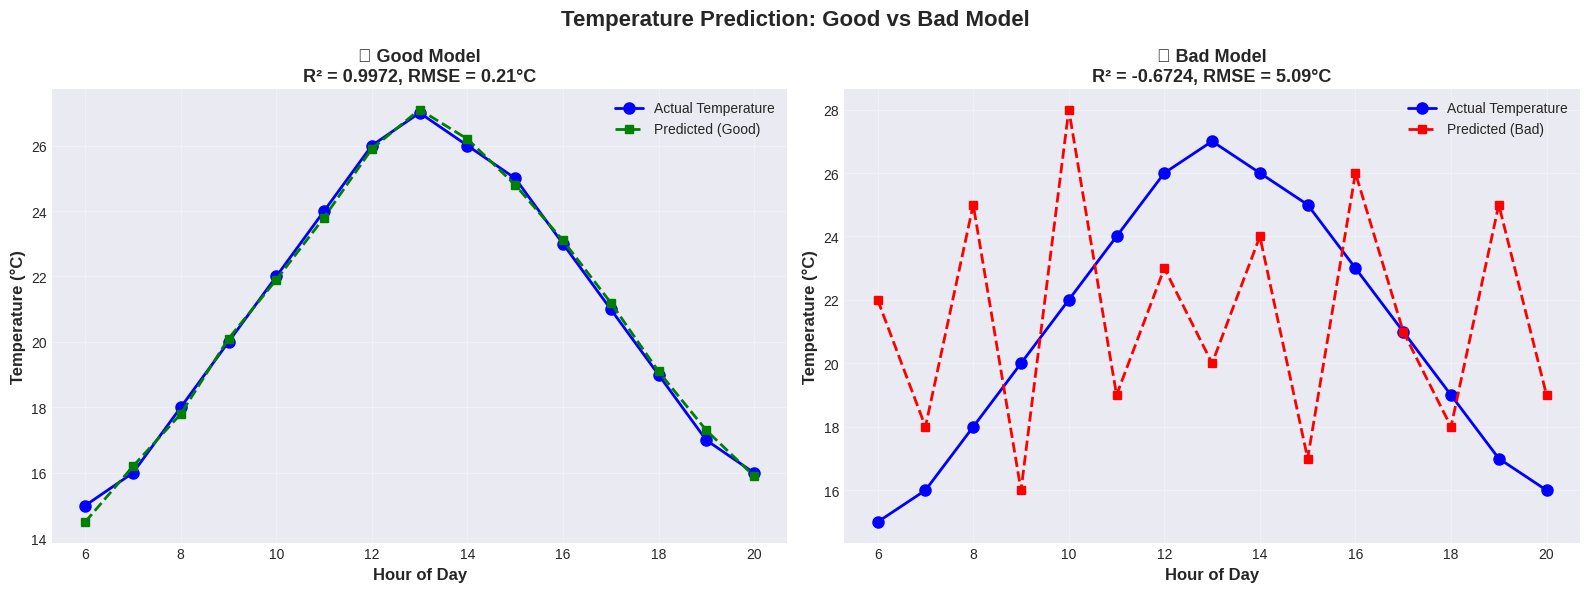

✅ Temperature prediction visualization created!


In [12]:
# Visualize temperature prediction example
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Temperature Prediction: Good vs Bad Model', fontsize=16, fontweight='bold')

# Good model
axes[0].plot(hours, actual_temp, 'o-', linewidth=2, markersize=8, label='Actual Temperature', color='blue')
axes[0].plot(hours, predicted_temp_good, 's--', linewidth=2, markersize=6, label='Predicted (Good)', color='green')
axes[0].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
axes[0].set_title(f'✅ Good Model\nR² = {r2_good_temp:.4f}, RMSE = {rmse_good_temp:.2f}°C', 
                 fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bad model
axes[1].plot(hours, actual_temp, 'o-', linewidth=2, markersize=8, label='Actual Temperature', color='blue')
axes[1].plot(hours, predicted_temp_bad, 's--', linewidth=2, markersize=6, label='Predicted (Bad)', color='red')
axes[1].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)', fontsize=12, fontweight='bold')
axes[1].set_title(f'❌ Bad Model\nR² = {r2_bad_temp:.4f}, RMSE = {rmse_bad_temp:.2f}°C', 
                 fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Temperature prediction visualization created!")

## 🎓 Summary and Key Takeaways

### ✅ What You've Learned:

1. **R² (R-Squared)**:
   - Measures how well predictions fit data
   - Range: -∞ to 1.0 (higher is better)
   - Formula: R² = 1 - (SS_res / SS_tot)
   - Interpretation: % of variance explained

2. **Correlation**:
   - Measures linear relationship strength
   - Range: -1.0 to +1.0
   - Formula: r = Σ[(x-x̄)(y-ȳ)] / √[Σ(x-x̄)² × Σ(y-ȳ)²]
   - |r| close to 1 = strong relationship

3. **MAE (Mean Absolute Error)**:
   - Average absolute error
   - Formula: MAE = (1/n) × Σ|errors|
   - Easy to interpret

4. **MSE (Mean Squared Error)**:
   - Average squared error
   - Formula: MSE = (1/n) × Σ(errors)²
   - Penalizes large errors heavily

5. **RMSE (Root Mean Squared Error)**:
   - Square root of MSE
   - Formula: RMSE = √MSE
   - Most commonly used

### 📚 Quick Reference:

| Metric | Range | Best Value | Interpretation |
|--------|-------|------------|----------------|
| **R²** | -∞ to 1 | 1.0 | Higher = Better |
| **Correlation** | -1 to +1 | ±1.0 | |r| closer to 1 = Stronger |
| **MAE** | 0 to ∞ | 0 | Lower = Better |
| **RMSE** | 0 to ∞ | 0 | Lower = Better |
| **MSE** | 0 to ∞ | 0 | Lower = Better |

### 💡 Remember:

- **Use multiple metrics** - Don't rely on just one!
- **R²** tells you how well the model fits
- **RMSE/MAE** tell you actual error size
- **Correlation** tells you relationship strength
- **Visualize** your data - plots help understand metrics!

---

**Great job learning data analytics metrics! 📊✨**